In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cmocean.cm as cmo

In [2]:
def create_long_lat(dx, nx, ny, beta_rot):
    r_earth = 6370.0 # radius of the Earth
    beta    = beta_rot   # to rotate the mask with respect to Greenwich
                     # when beta = 0, x and x1 axis are aligned with Greenwich
    if int(80 % dx)==0:
        dx_pole = 2480 + (80 - (dx / 2))  # distance of pole from tracer point of cell 0,0
        dy_pole = 2240 + (80 - (dx / 2))
    elif int(32 % dx)==0:
        dx_pole = 2464 + (32 - (dx / 2))  # distance of pole from tracer point of cell 0,0
        dy_pole = 2208 + (32 - (dx / 2)) 
    
    deg2rad = np.pi / 180
    rad2deg = 180 / np.pi
          
    latmin  = 90.0
    ilatmin = 0
    jlatmin = 0
    r1max   = 0

    lat = np.zeros((nx, ny))
    long = np.zeros((nx, ny))

    ii = np.arange(0, nx)
    jj = np.arange(0, ny)
    j, i = np.meshgrid(jj, ii)
    #---------- position on the stereographic plane -------------------------------
    x1 = i * dx - dx_pole
    y1 = j * dx - dy_pole
    r1 = np.sqrt(x1**2 + y1**2)
    if np.max(r1) > r1max:
        r1max = np.max(r1)
    #---------- angle of the cone -------------------------------------------------
    tanteta  = r1 / (2 * r_earth)
    #----------- short radius on the sphere ---------------------------------------
    r = 2 * r_earth * tanteta / (1 + tanteta**2)
    #----------- get the latitude and longitude -----------------------------------
    lat = np.arccos(r / r_earth) * rad2deg
    if np.min(lat < latmin):
        latmin = np.min(lat)
        ilatmin = i[np.unravel_index(lat.argmin(), lat.shape)]
        jlatmin = j[np.unravel_index(lat.argmin(), lat.shape)]
    x1 = np.where(((x1 >= 0.0) & (x1 < 1e-8)), 1e-8, x1)
    long = np.where(((x1 >= 0.0) & (y1 >= 0)), np.arctan(y1 / x1) * rad2deg + beta, long)
    long = np.where(((x1 >= 0.0) & (y1 < 0)), np.arctan(y1 / x1) * rad2deg + beta + 360.0, long)
    long = np.where((x1 < 0.0), np.arctan(y1 / x1) * rad2deg + beta + 180.0, long)
    long = np.where((long >= 360.0), long - 360.0, long)
    return long, lat

In [3]:
def nineptave(data, era5=False):
    winx = np.array([0.25, 0.5, 0.25])
    winy = np.array([0.25, 0.5, 0.25])
    window = xr.DataArray((winx[None, :] * winy[:, None]) / (np.sum(winx) * np.sum(winy)), dims=["winx", "winy"])
    if era5:
        out = data.rolling(longitude=3, latitude=3, min_periods=1, center=True).construct(longitude="winx", latitude="winy").dot(window)
    else:
        out = data.rolling(x=3, y=3, min_periods=1, center=True).construct(x="winx", y="winy").dot(window)
    return out

In [4]:
def geostrophy(data, dx):
    dxm = dx * 1e3
    u = -(data.g / (data.f.isel(y=slice(1, None)) + 0.5 * data.f.diff("y"))) * (data.diff("y") / dxm)
    v = (data.g / data.f.isel(x=slice(1, None))) * (data.diff("x") / dxm)
    return u, v

In [162]:
udata = xr.open_mfdataset("/storage/jrieck/ERA5/northOf55/ERA5_200701_10m_u_component_of_wind.grib").isel(time=slice(0, 6))
vdata = xr.open_mfdataset("/storage/jrieck/ERA5/northOf55/ERA5_200701_10m_v_component_of_wind.grib").isel(time=slice(0, 6))
udata["longitude"] = udata.longitude.where(udata.longitude >= 0, udata.longitude + 360)
udata = udata.sortby("longitude")
vdata["longitude"] = vdata.longitude.where(vdata.longitude >= 0, vdata.longitude + 360)
vdata = vdata.sortby("longitude")

# extend data by 1 in x direction for smooth interpolation across -180/180 boundary
# u and v from ERA5 are on the same longitude and latitude, se we use only the ones from udata
periodic = xr.Dataset()
periodic["time"] = (("time"), udata.valid_time.data)
periodic["longitude"] = (("longitude"), np.hstack([udata.longitude.where(udata.longitude >= 0, udata.longitude + 360), 360.]))
periodic["latitude"] = (("latitude"), udata.latitude.data)
periodic["u10"] = (("time", "latitude", "longitude"), np.concatenate([udata.u10.values, 
                                                                      udata.u10.isel(longitude=slice(0, 1)).values], axis=2))
periodic["v10"] = (("time", "latitude", "longitude"), np.concatenate([vdata.v10.values, 
                                                                      vdata.v10.isel(longitude=slice(0, 1)).values], axis=2))

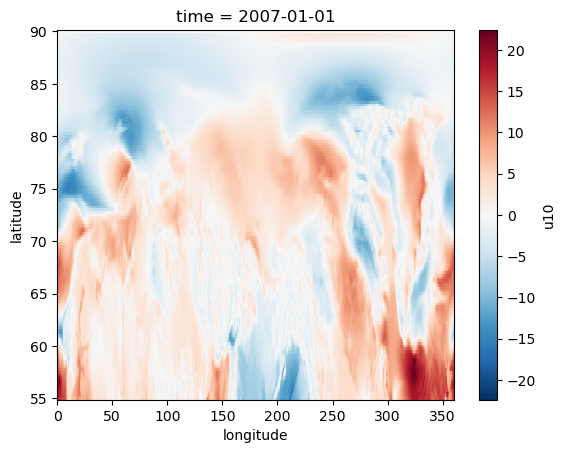

In [163]:
periodic["u10"].isel(time=0).plot()

first compute wind on 1 km grid

In [164]:
dx = 1.0
nx = 5120
ny = 4320
beta_rot = 32.0

In [165]:
lon, lat = create_long_lat(dx, nx+2, ny+2, 32.0)

In [166]:
gridT = xr.Dataset()
gridT["lon"] = (("y", "x"), lon)
gridT["lat"] = (("y", "x"), lat)

In [167]:
gridU = xr.Dataset()
gridU["lon"] = (("y", "x"), gridT.lon.interp(x=np.arange(0.5, np.max(gridT.x.values))).values)
gridU["lat"] = (("y", "x"), gridT.lat.interp(x=np.arange(0.5, np.max(gridT.x.values))).values)

In [168]:
gridV = xr.Dataset()
gridV["lon"] = (("y", "x"), gridT.lon.interp(y=np.arange(0.5, np.max(gridT.y.values))).values)
gridV["lat"] = (("y", "x"), gridT.lat.interp(y=np.arange(0.5, np.max(gridT.y.values))).values)

use native 2D linear interpolation from xarray (numpy/scipy)

In [169]:
uForcing = periodic.u10.interp(longitude=gridU.lon, latitude=gridU.lat)

In [170]:
vForcing = periodic.v10.interp(longitude=gridV.lon, latitude=gridV.lat)

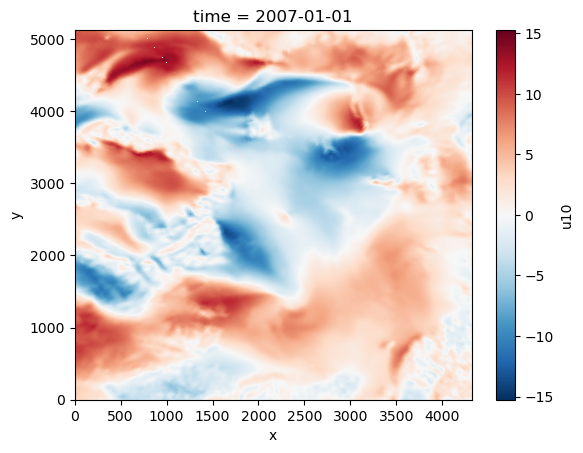

In [ ]:
uForcing.isel(time=0).plot()

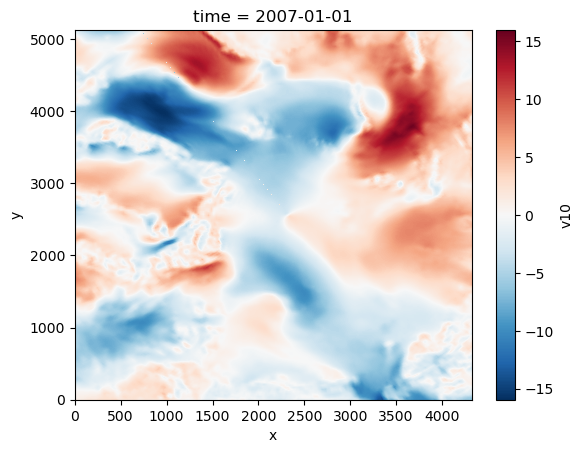

In [ ]:
vForcing.isel(time=0).plot()

In [571]:
gridU

<xarray.Dataset>
Dimensions:  (y: 5122, x: 4321)
Dimensions without coordinates: y, x
Data variables:
    lon      (y, x) float64 254.2 254.2 254.2 254.1 ... 69.95 69.97 69.98 70.0
    lat      (y, x) float64 59.66 59.67 59.67 59.68 ... 61.39 61.38 61.38 61.37

cubic 2D is not implemented so we have to first do east-west and then north-south

In [381]:
# get coeffcients for Lagrangian polynomials
def LAG2(i, x, a, sp):
    numer = np.ones_like(x)
    denom = np.ones_like(x)
    for k in range(0, sp):
        if ( k != i):
            denom = denom * (a[i, :, :] - a[k, :, :])
            numer = numer * (x    - a[k, :, :])
    return numer / denom

In [594]:
def interpolate(data, target_grid, method="linear"):
    if method == "linear":
        sp = 2
    elif method == "cubic":
        sp = 4
    # prepare input grid and data (extending beyond real boundaries to avoid problems when interpolating)
    nxIn = len(data.longitude.values)
    nyIn = len(data.latitude.values)
    lon_0 = np.min(data.longitude.values)
    lon_inc = data.longitude.values[1] - data.longitude.values[0]
    lat_0 = np.min(data.latitude.values)
    lat_inc = data.latitude.values[0] - data.latitude.values[1]
    x_in = lon_0 + (np.arange(-2, nxIn+2) * lon_inc)
    y_in = lat_0 + (np.arange(-2, nyIn+2) * lat_inc)
    arrayin = np.zeros((len(data.time), len(y_in), len(x_in)))
    arrayin[:, 2:-2, 2:-2] = data.values[:, ::-1, :]
    arrayin[:, :, 1] = arrayin[:, :, -3]
    arrayin[:, :, 0] = arrayin[:, :, -4]
    arrayin[:, :, -2] = arrayin[:, :, 2]
    arrayin[:, :, -1] = arrayin[:, :, 3]
    arrayin[:, 1, :] = arrayin[:, 2, :]
    arrayin[:, 0, :] = arrayin[:, 2, :]
    arrayin[:, -1, :] = arrayin[:, -3, :]
    arrayin[:, -2, :] = arrayin[:, -3, :]
    # prepare target grid
    xG = target_grid.lon.values
    yG = target_grid.lat.values
    nx = np.shape(xG)[1]
    ny = np.shape(xG)[0]
    arrayout = target_grid.copy()
    # find indeces in old grid that correspond to values in target grid
    tmp_ind = np.zeros((ny, nx)) + nyIn + 1
    s_ind = np.zeros((ny, nx))
    tmpVar = len(y_in) + 1e-3
    nLoop = 1 + int(np.log(tmpVar) / np.log(2.))
    for l in range(0, nLoop):
         for j in range(0, ny):
                for i in range(0, nx):
                    if ( tmp_ind[j, i] >= s_ind[j, i] + 1 ):
                        k = int((s_ind[j, i] + tmp_ind[j, i]) * 0.5)
                        if ( yG[j, i] <= y_in[k] ):
                            tmp_ind[j, i] = k
                        else:
                            s_ind[j, i] = k
    
    w_ind = np.around(((xG - x_in[0])/lon_inc) - 1).astype(int)
    s_ind = s_ind.astype(int)
    px_ind = np.zeros((sp, ny, nx))
    py_ind = np.zeros((sp, ny, nx))
    if sp == 2:
        for l in range(0, sp):
            px_ind[l, :, :] = x_in[w_ind+l]
            py_ind[l, :, :] = y_in[s_ind+l]
        sp = 2
        LAG0x = LAG2(0, xG, px_ind, sp)
        LAG1x = LAG2(1, xG, px_ind, sp)
        LAG0y = LAG2(0, yG, py_ind, sp)
        LAG1y = LAG2(1, yG, py_ind, sp)
        arrayout[data.name] = ((("time", "y", "x"), ((arrayin[:, s_ind, w_ind] * LAG0x + arrayin[:, s_ind, w_ind+1] * LAG1x) * LAG0y 
                                   + (arrayin[:, s_ind+1, w_ind] * LAG0x + arrayin[:, s_ind+1, w_ind+1] * LAG1x) * LAG1y)))
    elif sp == 4:
        for l in range(0, sp):
            px_ind[l, :, :] = x_in[w_ind+l-1]
            py_ind[l, :, :] = y_in[s_ind+l-1]
        LAG0x = LAG2(0, xG, px_ind, sp)
        LAG1x = LAG2(1, xG, px_ind, sp)
        LAG2x = LAG2(2, xG, px_ind, sp)
        LAG3x = LAG2(3, xG, px_ind, sp)
        LAG0y = LAG2(0, yG, py_ind, sp)
        LAG1y = LAG2(1, yG, py_ind, sp)
        LAG2y = LAG2(2, yG, py_ind, sp)
        LAG3y = LAG2(3, yG, py_ind, sp)
        arrayout[data.name] = ((("time", "y", "x"), ((arrayin[:, s_ind-1, w_ind-1] * LAG0x + arrayin[:, s_ind-1, w_ind] * LAG1x 
                                                        + arrayin[:, s_ind-1, w_ind+1] * LAG2x + arrayin[:, s_ind-1, w_ind+2] * LAG3x) * LAG0y 
                                                   + (arrayin[:, s_ind, w_ind-1] * LAG0x + arrayin[:, s_ind, w_ind] * LAG1x 
                                                        + arrayin[:, s_ind, w_ind+1] * LAG2x + arrayin[:, s_ind, w_ind+2] * LAG3x) * LAG1y 
                                                   + (arrayin[:, s_ind+1, w_ind-1] * LAG0x + arrayin[:, s_ind+1, w_ind] * LAG1x 
                                                        + arrayin[:, s_ind+1, w_ind+1] * LAG2x + arrayin[:, s_ind+1, w_ind+2] * LAG3x) * LAG2y 
                                                   + (arrayin[:, s_ind+2, w_ind-1] * LAG0x + arrayin[:, s_ind+2, w_ind] * LAG1x 
                                                        + arrayin[:, s_ind+2, w_ind+1] * LAG2x + arrayin[:, s_ind+2, w_ind+2] * LAG3x) * LAG3y)))
    return arrayout

In [589]:
test_linear = interpolate(udata.u10, gridU, method="linear")

In [595]:
test_cubic = interpolate(udata.u10, gridU, method="cubic")

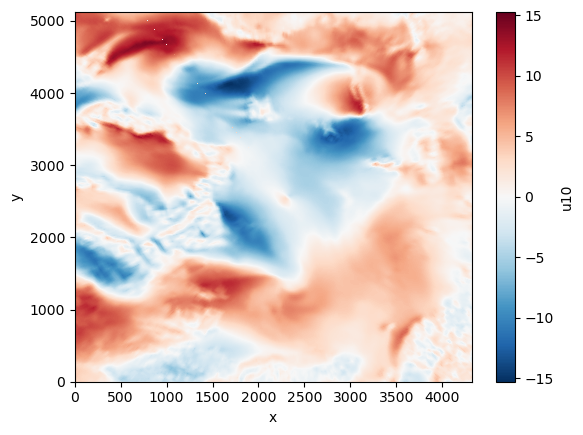

In [591]:
test_linear.u10.isel(time=0).plot()

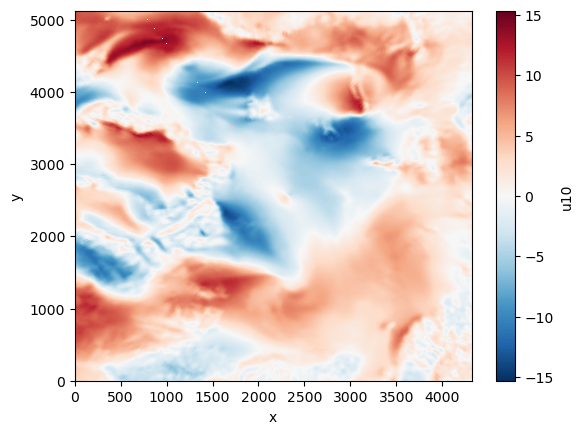

In [596]:
test_cubic.u10.isel(time=0).plot()

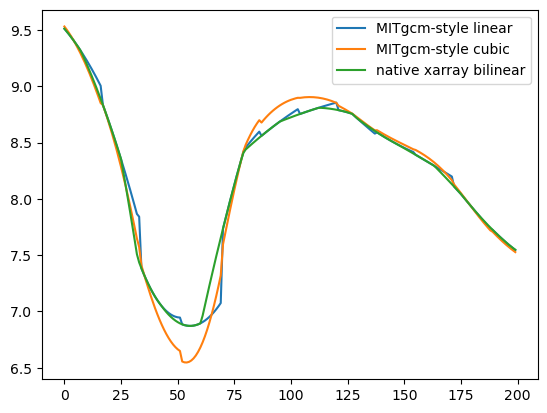

In [609]:
plt.plot(test_linear.u10[0, 5000, 300:500], label="MITgcm-style linear")
plt.plot(test_cubic.u10[0, 5000, 300:500], label="MITgcm-style cubic")
plt.plot(uForcing.values[0, 5000, 300:500], label="native xarray bilinear")
plt.legend()